In [26]:
import pandas as pd 
import os 
import seaborn as sns 
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, brier_score_loss, log_loss)
import numpy as np
from sklearn.calibration import calibration_curve, CalibrationDisplay
import warnings

warnings.filterwarnings('ignore')

In [2]:
data_path = os.path.join('..','data', 'processed', 'dados_modelagem.csv')
df = pd.read_csv(data_path)
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df = df.set_index('data')
df.head()

,Produção de derivados de petróleo,Consumo de derivados de petróleo - gasolina,Consumo de derivados de petróleo - Óleo combustível,Selic,Cambio - IPCA,IPCA,Producao Industrial,Balança comercial,IBC-Br,Close_PETR4.SA,Volume_PETR4.SA,Close_IBOV,BETA,regime
data,,,,,,,,,,,,,,
2004-01-01,1457.0,287.0,91.0,1.27,130.93,0.76,89.5,1507.1,72.33564,1.841724,987574400,21851.0,0.766782,0.0
2004-02-01,1452.0,283.0,90.0,1.08,137.73,0.61,86.3,1897.7,73.04534,1.929000,812371200,21755.0,0.477635,0.0
2004-03-01,1480.0,294.0,100.0,1.38,135.51,0.47,101.3,2462.5,73.85742,2.011334,768102400,22142.0,0.452186,0.0
2004-04-01,1449.0,311.0,96.0,1.18,135.10,0.37,95.8,1841.5,74.27324,1.757272,777699200,19607.0,0.717028,0.0
2004-05-01,1421.0,278.0,84.0,1.23,142.57,0.51,100.6,2995.7,74.19837,1.688581,971433600,19545.0,0.743726,0.0


<Axes: title={'center': 'Mapa de calor - correlaçao'}>

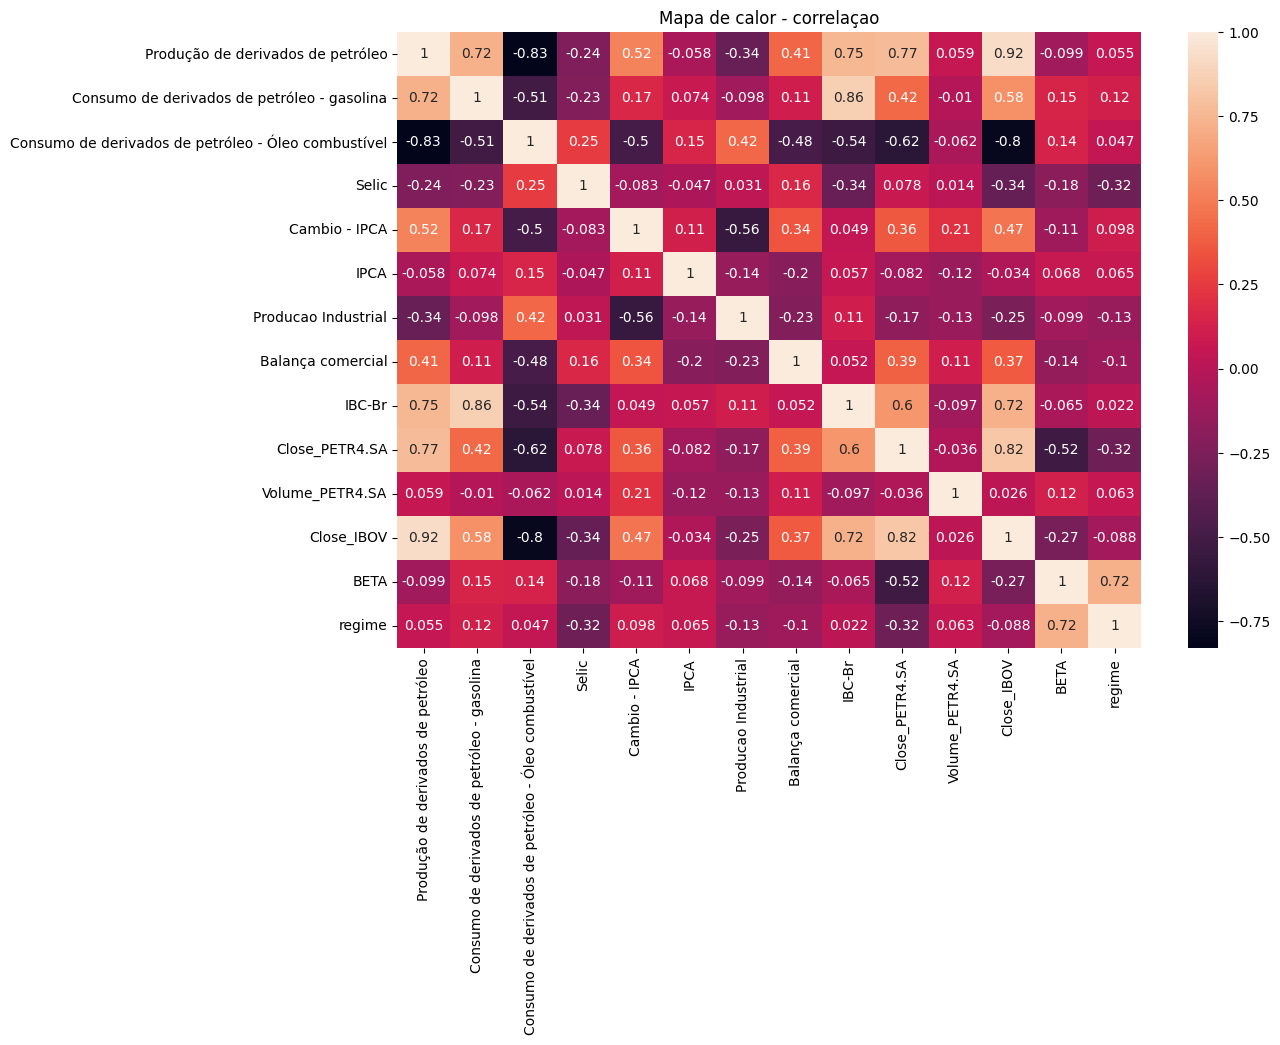

In [3]:
corr = df.corr()
plt.figure(figsize=(12,8))
plt.title('Mapa de calor - correlaçao')
sns.heatmap(corr, annot=True)

In [4]:
df.columns

Index(['Produção de derivados de petróleo',
       'Consumo de derivados de petróleo - gasolina',
       'Consumo de derivados de petróleo - Óleo combustível', 'Selic',
       'Cambio - IPCA', 'IPCA', 'Producao Industrial', 'Balança comercial',
       'IBC-Br', 'Close_PETR4.SA', 'Volume_PETR4.SA', 'Close_IBOV', 'BETA',
       'regime'],
      dtype='object')

In [5]:
df = df[['Produção de derivados de petróleo', 'IBC-Br', 'BETA', 'regime']]
df

,Produção de derivados de petróleo,IBC-Br,BETA,regime
data,,,,
2004-01-01,1457.0,72.33564,0.766782,0.0
2004-02-01,1452.0,73.04534,0.477635,0.0
2004-03-01,1480.0,73.85742,0.452186,0.0
2004-04-01,1449.0,74.27324,0.717028,0.0
2004-05-01,1421.0,74.19837,0.743726,0.0
...,...,...,...,...
2025-11-01,3773.0,109.28228,0.284707,0.0
2025-12-01,4015.0,109.29356,0.033498,0.0
2026-01-01,3953.0,110.22869,1.064134,0.0


In [6]:
df['pct_Produção de derivados de petróleo'] = df['Produção de derivados de petróleo'].pct_change(6)
df['pct_IBC-Br'] = df['IBC-Br'].pct_change(6)
df = df.drop(['Produção de derivados de petróleo', 'IBC-Br'], axis=1)

In [7]:
df = df.dropna()
df[df['regime']==1]

,BETA,regime,pct_Produção de derivados de petróleo,pct_IBC-Br
data,,,,
2008-07-01,1.405721,1.0,0.027590,0.023371
2008-08-01,1.368284,1.0,0.038939,0.028618
2008-09-01,1.203446,1.0,0.061143,0.034575
2008-10-01,1.319166,1.0,0.020033,0.001153
2008-11-01,1.286090,1.0,-0.004408,-0.033414
...,...,...,...,...
2021-06-01,1.800960,1.0,0.064930,-0.009849
2021-07-01,1.957086,1.0,0.059868,-0.014401
2021-08-01,1.964089,1.0,0.063143,-0.017603


In [8]:
df.corr()

,BETA,regime,pct_Produção de derivados de petróleo,pct_IBC-Br
BETA,1.000000,0.719516,0.046869,-0.320027
regime,0.719516,1.000000,-0.016431,-0.359214
pct_Produção de derivados de petróleo,0.046869,-0.016431,1.000000,-0.086170
pct_IBC-Br,-0.320027,-0.359214,-0.086170,1.000000


In [9]:
# funçao de metricas 
def metrics(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ks = max(tpr-fpr)
    brier_score = brier_score_loss(y_true, y_score)
    log_loss_score =log_loss(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    results = {
            'KS':ks, 
            'Brier Score':brier_score, 
            'Log Loss': log_loss_score, 
            'ROC_AUC':roc_auc
        }
    return pd.DataFrame([results])

In [10]:
# modelos 
models = {
    'XGBoost': XGBClassifier(), 
    'GradientBoost': GradientBoostingClassifier(random_state=42), 
    'DecisionTree': DecisionTreeClassifier(random_state=42), 
    'RandomForest':RandomForestClassifier(random_state=42), 
    'AdaBoost':AdaBoostClassifier(random_state=42)
}

In [11]:
# split temporal treino x teste 
df_train = df.loc['2004-01-01':'2020-12-01']
df_test = df.loc['2021-01-01':]

In [12]:
# separaçao treino x teste
y_train = df_train['regime']
X_train = df_train.drop('regime', axis=1)
y_test = df_test['regime']
X_test = df_test.drop('regime', axis=1)

treinando modelo XGBoost
metrics treino:
    KS  Brier Score  Log Loss  ROC_AUC
0  1.0      0.00373   0.03065      1.0
metrics teste:
         KS  Brier Score  Log Loss   ROC_AUC
0  0.843396     0.056101  0.198337  0.958491

treinando modelo GradientBoost
metrics treino:
    KS  Brier Score  Log Loss  ROC_AUC
0  1.0     0.002928  0.030673      1.0
metrics teste:
         KS  Brier Score  Log Loss   ROC_AUC
0  0.792453     0.048101  0.154438  0.966981

treinando modelo DecisionTree
metrics treino:
    KS  Brier Score      Log Loss  ROC_AUC
0  1.0          0.0  2.220446e-16      1.0
metrics teste:
         KS  Brier Score  Log Loss   ROC_AUC
0  0.824528     0.079365  2.860607  0.912264

treinando modelo RandomForest
metrics treino:
    KS  Brier Score  Log Loss  ROC_AUC
0  1.0     0.010597  0.069701      1.0
metrics teste:
         KS  Brier Score  Log Loss   ROC_AUC
0  0.881132     0.048646  0.173764  0.983019

treinando modelo AdaBoost
metrics treino:
         KS  Brier Score  Log Loss

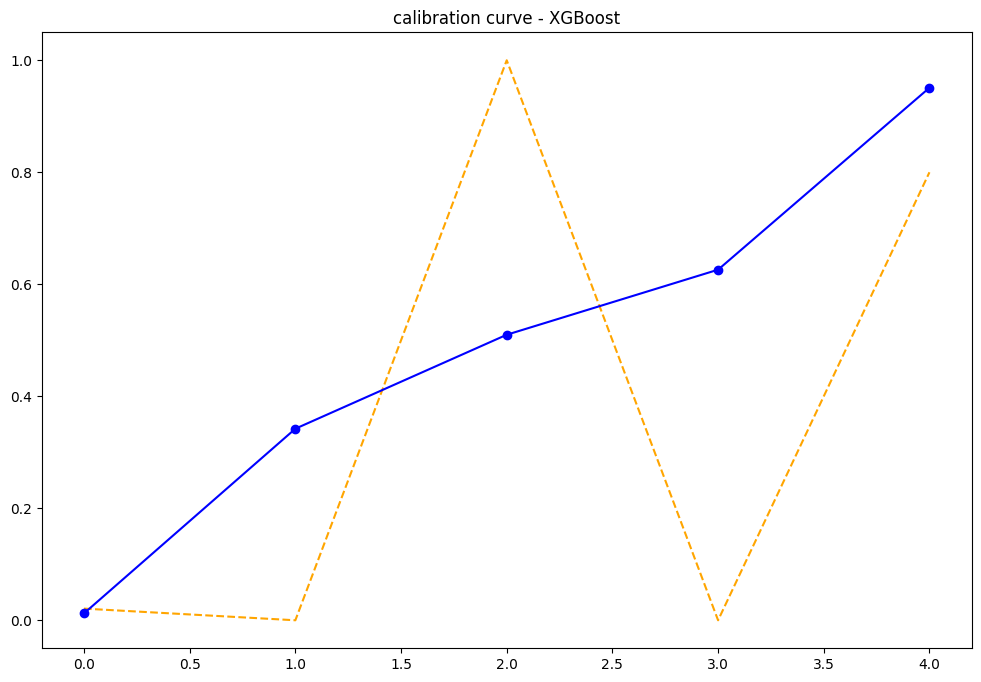

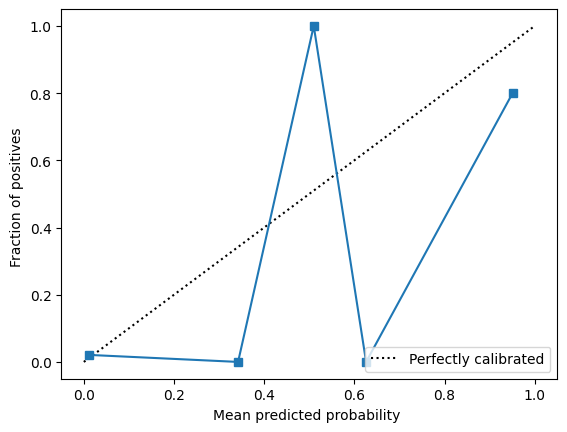

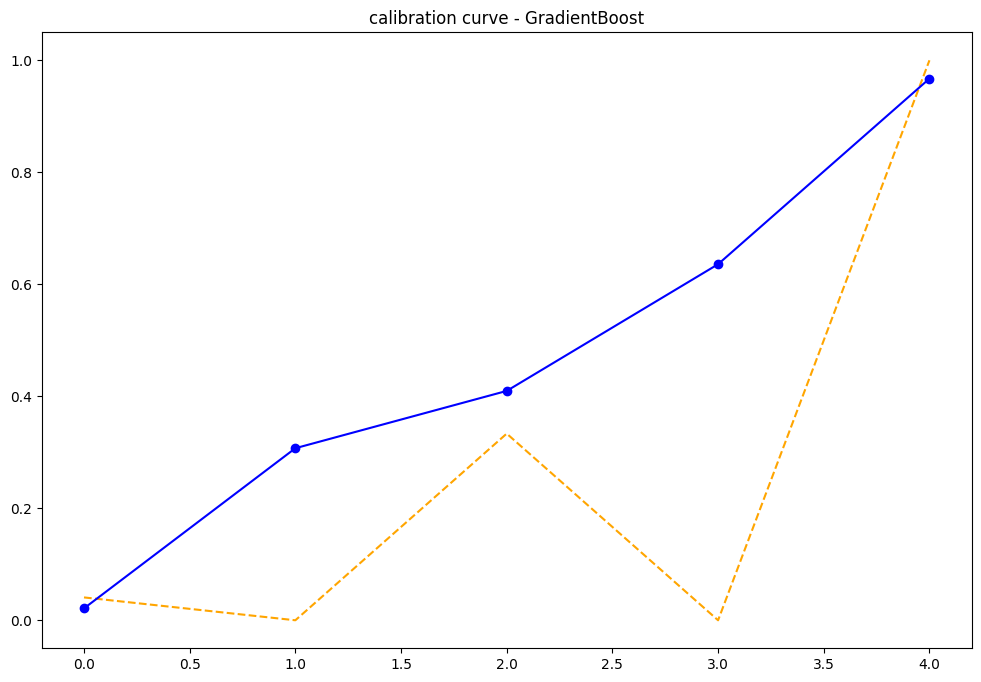

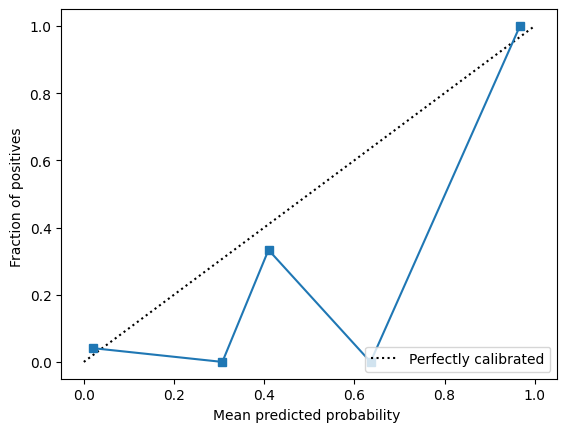

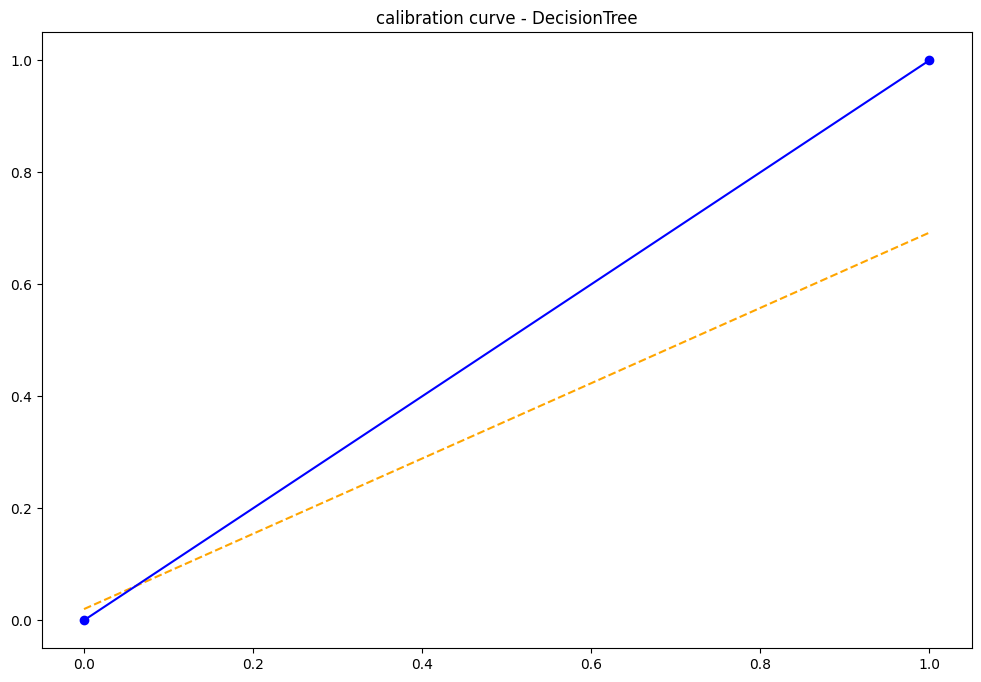

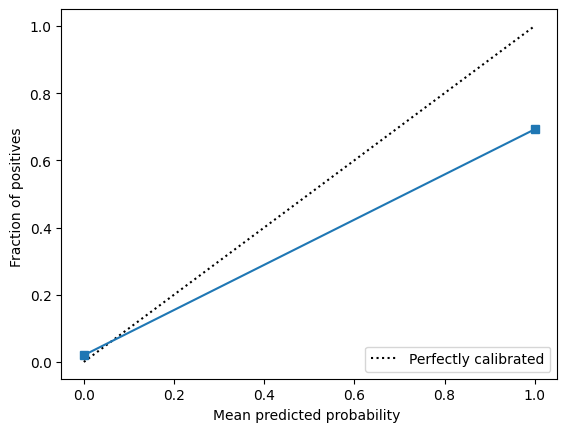

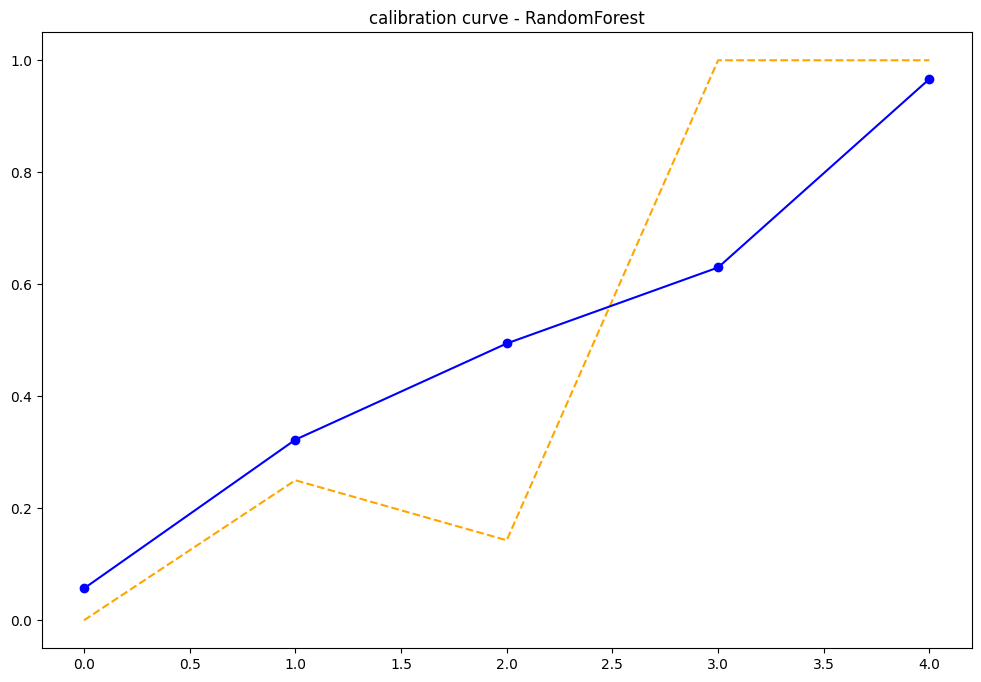

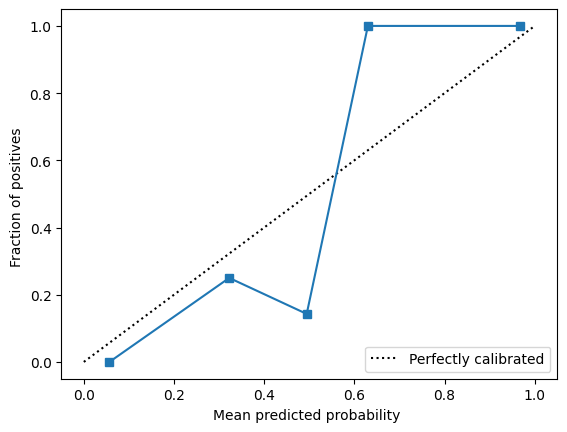

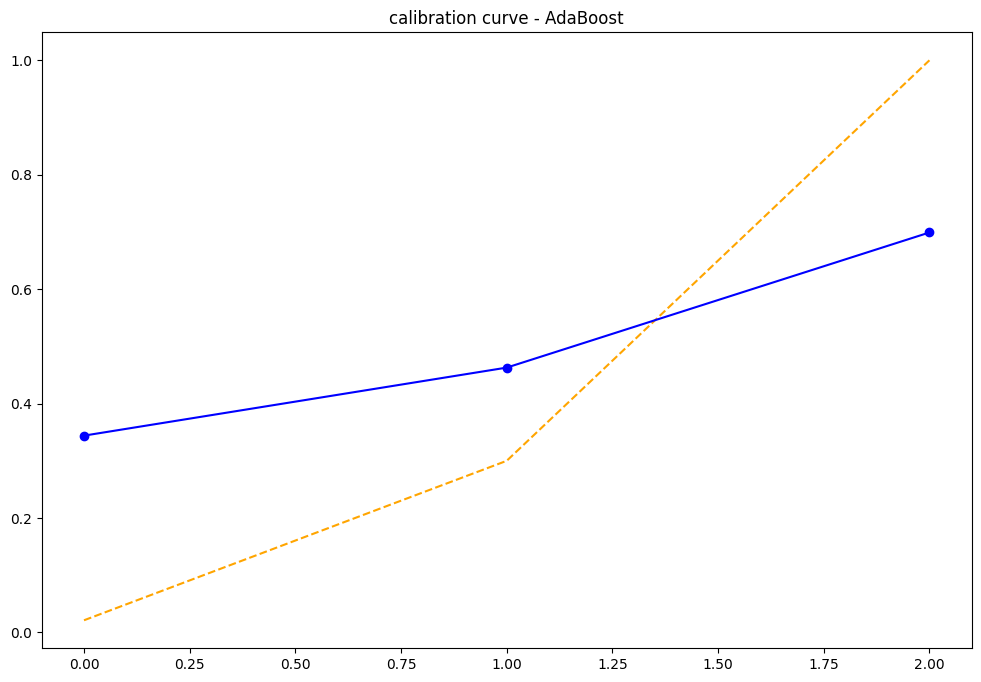

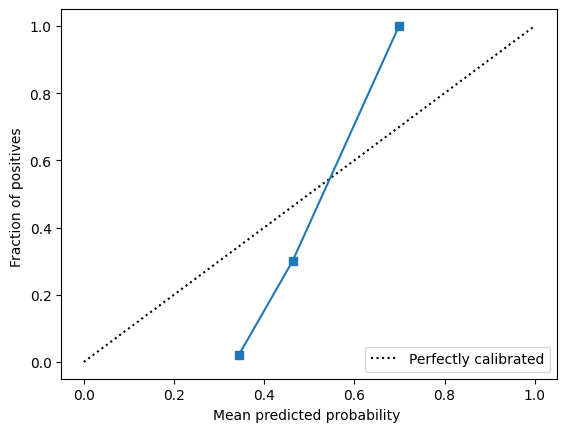

In [29]:
# rodando modelos 
for name, model in models.items():
    model_ = model.fit(X_train, y_train)
    train_pred = model_.predict_proba(X_train)[:,1]
    test_pred = model.predict_proba(X_test)[:,1]
    print(f'treinando modelo {name}')
    print('metrics treino:')
    print(f'{metrics(y_train, train_pred)}')
    print('metrics teste:')
    print(f'{metrics(y_test, test_pred)}')
    print("===="*50)
    print()
    prob_true, prob_pred = calibration_curve(y_test, test_pred)
    plt.figure(figsize=(12,8))
    plt.title(f'calibration curve - {name}')
    plt.plot(prob_true, color='orange', linestyle='--')
    plt.plot(prob_pred, color='blue', marker='o')
    
    disp = CalibrationDisplay(prob_true, prob_pred, test_pred)
    disp.plot()

O modelo selecionado para transiçao de regime é o modelo RandomForest

**Criando faixas de regime**

In [35]:
randomF = RandomForestClassifier().fit(X_train, y_train)
probs = randomF.predict_proba(X_test)[:,1]
probs

array([0.58, 0.45, 0.97, 0.92, 0.95, 0.95, 1.  , 0.99, 0.57, 0.2 , 0.04,
       0.01, 0.26, 0.05, 0.  , 0.06, 0.01, 0.04, 0.19, 0.1 , 0.09, 0.07,
       0.02, 0.02, 0.41, 0.09, 0.  , 0.03, 0.03, 0.04, 0.03, 0.54, 0.53,
       0.53, 0.04, 0.04, 0.01, 0.01, 0.01, 0.12, 0.13, 0.04, 0.  , 0.04,
       0.14, 0.06, 0.01, 0.02, 0.03, 0.02, 0.  , 0.04, 0.04, 0.06, 0.36,
       0.4 , 0.4 , 0.41, 0.15, 0.16, 0.01, 0.07, 0.03])

In [38]:
regime_bands = pd.qcut(probs, 2, labels=['No regime', 'In Transition'])
regime_bands

['In Transition', 'In Transition', 'In Transition', 'In Transition', 'In Transition', ..., 'In Transition', 'In Transition', 'No regime', 'In Transition', 'No regime']
Length: 63
Categories (2, object): ['No regime' < 'In Transition']

In [40]:
regime_values = pd.qcut(probs, 2)
regime_values

[(0.06, 1.0], (0.06, 1.0], (0.06, 1.0], (0.06, 1.0], (0.06, 1.0], ..., (0.06, 1.0], (0.06, 1.0], (-0.001, 0.06], (0.06, 1.0], (-0.001, 0.06]]
Length: 63
Categories (2, interval[float64, right]): [(-0.001, 0.06] < (0.06, 1.0]]

In [67]:
def risk_bands_func(probs:float):
    if probs <0.06 and probs >-0.001:
        return 'No regime'
    if probs > 0.06 and probs <=1:
        return 'In Transition'

In [68]:
risk_bands_func(0.05)

'No regime'